# Chapter 5, Example 3b
## Three-way data split on Iris data - multiple experiments

In [13]:
import torch
from torch import nn

from sklearn import datasets

# Helper libraries
import numpy as np
import matplotlib.pyplot as plt

In [14]:
class FFN(nn.Module):
    def __init__(self, no_features, hidden_units, no_labels):
        super(FFN, self).__init__()
        self.relu_stack = nn.Sequential(
            nn.Linear(no_features, hidden_units),
            nn.ReLU(),
            nn.Linear(hidden_units, no_labels),
        )

    def forward(self, x):
        logits = self.relu_stack(torch.tensor(x, dtype=torch.float32))
        return logits

In [15]:
def train_exp( X, Y, no_inputs, no_outputs, hidden_units, lr, no_epochs):

    x_train, y_train = X[:50], Y[:50]
    x_valid, y_valid = X[50:100], Y[50:100] 
    x_test, y_test = X[100:], Y[100:]

    loss_fn = torch.nn.CrossEntropyLoss()

    
    acc = []
    for no_hidden in hidden_units:
        
        model = FFN(no_inputs, no_hidden, no_outputs)
    
        optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    
        for epoch in range(no_epochs):
            pred = model(x_train)
            loss = loss_fn(pred, torch.tensor(y_train, dtype=torch.long))
    
            # Backpropagation
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
    
        pred = model(x_valid)
        acc_ = (pred.argmax(1) == y_valid).type(torch.float).mean()
    
        acc.append(acc_.item())
        
    no_hidden = hidden_units[np.argmax(acc)]
    
    x_train, y_train = X[:100], Y[:100]
    
    model = FFN(no_inputs, no_hidden, no_outputs)
    
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    
    for epoch in range(no_epochs):
        pred = model(x_train)
        loss = loss_fn(pred, torch.tensor(y_train, dtype=torch.long))
    
        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    
    pred = model(x_test)
    acc_ = (pred.argmax(1) == y_test).type(torch.float).mean()

    
    return no_hidden, acc_

In [16]:
# read data
iris = datasets.load_iris()

no_data = len(iris.data)
no_features = np.shape(iris.data)[1]
no_labels = len(np.unique(iris.target))

# center the data
X = iris.data - np.mean(iris.data, axis=0)
Y = iris.target

print(X.shape, Y.shape)

(150, 4) (150,)


In [17]:
lr = 0.1
no_epochs = 1000

hidden_units = [2, 4, 6, 8, 10, 12]

no_exps = 10

seed = 10
torch.manual_seed(seed)
np.random.seed(seed)

In [18]:

idx = np.arange(no_data)
no_hidden, acc = [], []
for exp in range(no_exps):
        
    np.random.shuffle(idx)
    
    no_hidden_, acc_ = train_exp(X[idx], Y[idx], no_features, no_labels, hidden_units, lr, no_epochs)
        
    no_hidden.append(no_hidden_)
    acc.append(acc_)
    print('exp %d: hidden units %d, accuracy %g'%(exp, no_hidden[exp], acc[exp]))

exp 0: hidden units 8, accuracy 1
exp 1: hidden units 12, accuracy 0.98
exp 2: hidden units 2, accuracy 0.92
exp 3: hidden units 12, accuracy 0.98
exp 4: hidden units 2, accuracy 0.98
exp 5: hidden units 2, accuracy 0.98
exp 6: hidden units 2, accuracy 0.96
exp 7: hidden units 2, accuracy 0.98
exp 8: hidden units 2, accuracy 0.6
exp 9: hidden units 2, accuracy 0.3


In [19]:
hidden_counts = np.zeros(len(hidden_units))
for exp in range(no_exps):
    hidden_counts[no_hidden[exp]//2-1] += 1
    
opt_hidden = hidden_units[np.argmax(hidden_counts)]
print('* %d hidden unit *'%opt_hidden)

* 2 hidden unit *


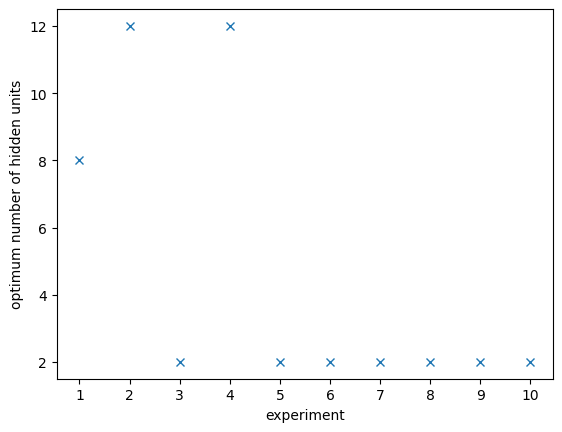

In [20]:
plt.figure(1)
plt.plot(range(no_exps), no_hidden, marker = 'x', linestyle = 'None')
plt.yticks(hidden_units)
plt.xticks(range(no_exps), np.arange(no_exps)+1)
plt.xlabel('experiment')
plt.ylabel('optimum number of hidden units')
plt.show()

In [ ]:
idx = np.arange(no_data)
np.random.shuffle(idx)
X, Y = X[idx], Y[idx]

x_train, y_train = X[:100], Y[:100]
x_test, y_test = X[100:], Y[100:]
   
model = FFN(no_features, opt_hidden, no_labels)

loss_fn = torch.nn.CrossEntropyLoss()

optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    
for epoch in range(no_epochs):
    pred = model(x_train)
    loss = loss_fn(pred, torch.tensor(y_train, dtype=torch.long))
    
    # Backpropagation
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    if epoch % 100 == 0:
        print('epoch %d, loss = %g'%(epoch, loss.item()))

pred = model(x_test)
acc_ = (pred.argmax(1) == y_test).type(torch.float).mean()

print('hidden units %d, mean accuracy = %g'%(opt_hidden, acc_))

epoch 0, loss = 1.0485
epoch 100, loss = 0.369799
epoch 200, loss = 0.260112
epoch 300, loss = 0.191977
epoch 400, loss = 0.146341
epoch 500, loss = 0.117802
epoch 600, loss = 0.100608
epoch 700, loss = 0.0897679
epoch 800, loss = 0.08252
epoch 900, loss = 0.0773806
hidden units 2, mean accuracy = 1
